# Introduction

In this notebook new poses are going to be defined based on unique geometric features of the target object. Concepts involving the contents from other notebooks will be used. These include:

   - Depth Map Calculation
   - Blob Detection
   - Plotting 3D Objects
    
Besides numpy, Opencv, and Matplotlib, other unique Python modules/libraries required for these notebook include:

   1. Zoe-Depth - To calculate Depth maps from monocular images
   2. Open3D - To calculate point clouds and normlas
   3. RemBG - To extract the object from the viewpoint image
   4. PyVista - To visualise in 3
   5. Scikit Image - To extract Features from 2D images
    
The notebook will explore the process from loading a preliminary viewpoint to derivation of a single camera pose.

In [1]:
import time
begin = time.time()
"""
    Get all the necessary modules  mentioned above loaded in
"""
import matplotlib.pyplot as plt
import cv2
import numpy as np
import matplotlib.gridspec as gridspec

# Import ZoeDepth
import torch
from zoedepth.models.builder import build_model
from zoedepth.utils.config import get_config
from zoedepth.utils.misc import colorize

# Import Open3D
import open3d as o3d

# Import Pyvista and set backend-trame
import pyvista as pv
pv.set_jupyter_backend('trame')

# Import RemBG
from rembg import remove, new_session

# Import 
from skimage import feature, io, color, img_as_float, filters
from skimage.feature import blob_dog, blob_log, blob_doh
from skimage.filters import sobel, scharr
from skimage.exposure import adjust_log

%matplotlib notebook

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
"""
    Define Some Helper Functions for Coveniences
"""

def load_image(img_name, img_dir="testImages/"):
    """
    Loads in an image from the file system

    Args:
    - img_name (string): File name of the image.
    - img_dir (string): The relative directory in which the image is contained.

    Returns:
    - numpy.ndarray: The image as a 2D numpy array
    """
    return cv2.cvtColor(cv2.imread(img_dir+img_name), cv2.COLOR_BGR2RGB)

def compute_depth(image, dev="cpu"):
    """
    Loads in an image from the file system

    Args:
    - img_name (string): File name of the image.
    - img_dir (string): The relative directory in which the image is contained.

    Returns:
    - numpy.ndarray: The image as a 2D numpy array
    """
    DEVICE = "cuda" if dev == "cuda" and torch.cuda.is_available() else "cpu"
    zoe.to(DEVICE)
    depth_numpy = zoe.infer_pil(image)  # as numpy
    zoe.to('cpu')
    torch.cuda.empty_cache()  # Clear unused cached memory
    return depth_numpy

def show_image(image, label, colorbar=True):
    """
    Display an image with an optional colorbar.

    Parameters:
    image : array-like
        The image data. This can be any array-like object that is interpretable by `imshow`.
    label : str
        The title label for the image. This text will be displayed above the image.
    colorbar : bool, optional
        A flag to indicate whether a colorbar should be displayed alongside the image.
        If True (default), a colorbar is displayed. If False, no colorbar is shown.

    """
    _, ax = plt.subplots(layout="constrained")
    imgPlot = ax.imshow(image)
    ax.set_title(label)
    if colorbar: plt.colorbar( imgPlot, ax=ax )
        

def create_mask(image):
    '''
        Create a Mask out of an image
    '''
    model_name = "u2net" # sam, u2net, silueta, isnet-general-use
    session = new_session(model_name)
    mask = remove(image, only_mask=True, post_process_mask=True)
    return mask
    
def mask_out(mask, _img):
    '''
        Masks out part of the image
    '''
    to_mask= np.copy(_img) # create a copy of the depth map
    to_mask[mask == 0] = 0
    return to_mask

def grayscale_to_rgb(grayscale_image):
    """
    Convert a grayscale image to an RGB image by replicating the grayscale values across all three channels.

    Parameters:
    - grayscale_image (numpy.ndarray): The input grayscale image.

    Returns:
    - rgb_image (numpy.ndarray): The resulting RGB image.
    """
    # Stack the grayscale image across three channels
    rgb_image = np.stack((grayscale_image,) * 3, axis=-1)
    return rgb_image

# Creating a custom Exception based on widths
class UnmatchedDimensionsException(Exception):
    pass
    
if 'zoe' not in globals():
    conf = get_config("zoedepth", "infer")
    zoe = build_model(conf)


img_size [384, 512]


Using cache found in /home/kibzyzii/.cache/torch/hub/intel-isl_MiDaS_master
/opt/miniconda3/envs/zoe/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1670525539683/work/aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Params passed to Resize transform:
	width:  512
	height:  384
	resize_target:  True
	keep_aspect_ratio:  True
	ensure_multiple_of:  32
	resize_method:  minimal
Using pretrained resource url::https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_N.pt
Loaded successfully


# Preparations

The orginal input image is loaded in throught the `load_image()` and cached to the variable `image_col` function. Its depth map is then computed and and cached in the variable `image_dep`. Backgrounds of the two are then removed to retain the foreground(target object) as `image_col_m` and `image_dep_m` respectively.

EP Error /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1193 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_tensorrt.so with error: libnvinfer.so.8: cannot open shared object file: No such file or directory
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
EP Error /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1193 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_tensorrt.so with error: libnvinfer.so.8: cannot open shared object file: No such file or directory
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecut

<IPython.core.display.Javascript object>


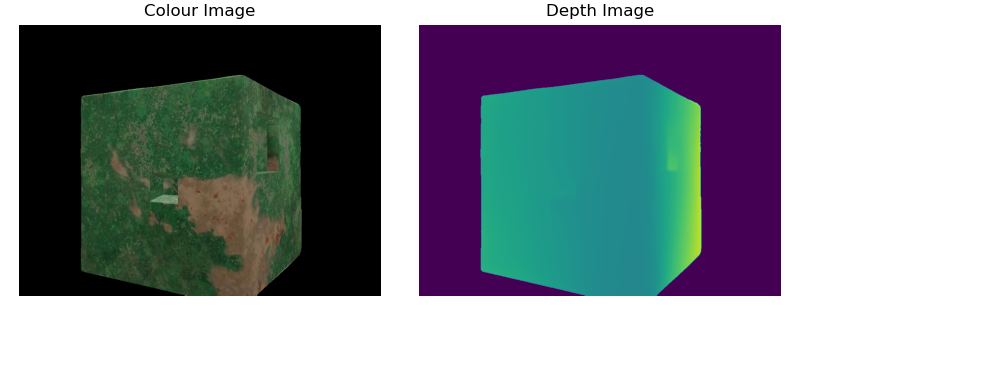

In [8]:
# Load Image from the ./testImages directory
image_col = load_image("33.jpg")

# Compute Depth Map
image_dep = compute_depth(image_col, dev="cuda")

# Mask out both Color and Depth images
mask = create_mask(image_col)
image_col_m = mask_out(mask, image_col)
image_dep_m = mask_out(mask, image_dep)

fig, axs = plt.subplots( 1, 2, figsize=(8,3), layout="constrained" )
for title, ax, img in zip([ "Colour Image", "Depth Image" ], axs, [ image_col_m, image_dep_m ]):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
    
    
img_width = image_col.shape[1]
img_height = image_col.shape[0]

# Calculate Occupancy
area = image_dep_m[image_dep_m > 0].size
occupancy = area/image_dep_m.size
occ_R = int(np.sqrt(area / np.pi))

# Calculate Camera Intrinsics
focal_l = 6.0
fx, fy = (focal_l *  img_width/6.287, focal_l *  img_width/6.287)
cx, cy = ( img_width/2, img_height/2 )
intrinsics = o3d.camera.PinholeCameraIntrinsic(img_width, img_height, fx, fy, cx, cy)

# Compute Features/Regions of Interest

The features(standout) for this will be the **edges** of the object as well as **blobs**. A **blob** is a region in a in image that differ significantly in properties such as brightness or colours relative to its surrounding regions whereas an **edge**  is a region with rapid change in image intensity. 

**NB: A knowledge of these regions allows the algorithm to identify what areas of the target object to give special attention**

Going by the descriptions of edges and blobs, we expect that given a depth map(typically gryscale), the feature present will hold only geometrical significance as the intensisties should ideally vary with depth for an ideal depth map.

Both functions have parameters that influence the sensitivity of the algorithms. These factors are sigma and threshold values.

For the blob, multiple blobs close to each other should be aggreated in such a way that fewer photos are taken. This could be through finding out the distance near or overlap between the blobs and if say 3 photos would be necessary for a single blob, 4 are taken instead that have both blobs in their field of view.

`scikit-image` offers methods to detect both of these feature while offering some customisations through some parameters. Common parameters for both feature detections are `sigma`($\sigma$) and `thresholds`. The `sigma`($\sigma$) parameter aims to reduce noise by applying a gaussian blur to the image. The `threshold`on the other hand are as the name suggests, they provides a low limit ovwe which detections are considered relevant. Blob detections however apply a range of sigma values:

> The blob detection algorithms operates in what is called a "scale-space" representation of an image, where the blobs are "searched" for at multiple scales within an image. The image is repeatedly blurred (usually with a Gaussian filter), and each blurred version represents the image at a different scale. The size of the blurring kernel $\sigma$ determines the scale.


In [14]:
def detect_edges(image, sigma=1, low_threshold=0.1):
    """
    Perform edge detection on an image.

    Parameters:
    - image (numpy.ndarray): The input image in numpy array format.
    - sigma (float): The standard deviation of the Gaussian filter used in edge detection.

    Returns:
    - edges: A numpy array representing the detected edges in the image.
    - Plots the image with detected edges.
    """
    
    # Convert image to grayscale if it's not already
    if len(image.shape) == 3:
        image = color.rgb2gray(image)

    # Convert image to float
    image = img_as_float(image)

    # Compute gradients in x and y directions
    grad_x = filters.sobel_h(image)
    grad_y = filters.sobel_v(image)

    # Compute the gradient magnitude
    grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    edges = feature.canny(image, sigma=sigma, low_threshold=low_threshold, high_threshold=.9)
    
    # Use Canny edges as a mask on the gradient magnitude image
    edge_strengths = grad_magnitude * edges    

    # Plotting
    plt.figure(figsize=(6, 6))
    plt.imshow(edge_strengths, cmap='gray')
    plt.title('Edge Detection')
    plt.axis('off')
    plt.show()

    return edge_strengths

    return edges;

def detect_blobs(image, blob_method='dog', min_sigma=1, max_sigma=30, num_sigma=10, threshold=.1):
    """
    Perform blob detection on an image.

    Parameters:
    - image (numpy.ndarray): The input image in numpy array format.
    - blob_method (str): Method for blob detection ('log', 'dog', 'doh').
    - min_sigma (float): The minimum standard deviation for Gaussian Kernel. Used in blob detection.
    - max_sigma (float): The maximum standard deviation for Gaussian Kernel. Used in blob detection.
    - num_sigma (int): The number of intermediate values of standard deviations to consider between min_sigma and max_sigma.
    - threshold (float): The absolute lower bound for scale space maxima. Lower values mean more blobs.

    Returns:
    - blobs: A numpy array with each row representing 3 values for each blob: (y-coordinate, x-coordinate, radius)
    - Plots the image with blobs marked.
    """

    if blob_method == 'log':  # Laplacian of Gaussian
        blobs = blob_log(image, min_sigma=min_sigma, max_sigma=max_sigma, num_sigma=num_sigma, threshold=threshold)
    elif blob_method == 'dog':  # Difference of Gaussian
        blobs = blob_dog(image, min_sigma=min_sigma, max_sigma=max_sigma, threshold=threshold)
    elif blob_method == 'doh':  # Determinant of Hessian
        blobs = blob_doh(image, min_sigma=min_sigma, max_sigma=max_sigma, threshold=threshold)
    else:
        raise ValueError("Invalid blob detection method")

    # Plotting
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image, interpolation='nearest')
    for blob in blobs:
        y, x, r = blob
        c = plt.Circle((x, y), r, color='red', linewidth=2, fill=False)
        ax.add_patch(c)
    ax.set_title('Blob Detection')
    ax.axis('off')
    plt.show()

    return blobs

### Execution

- Compute the Edges of the Masked Colour Image to get and edge map `edge_map`, **Figure 2**
- Compute the blobs from the masked Depth Image to get a list of blobs: `blobs`, **Figure 3**
- Compute the blobs form the `edge_map` to get a list of blobs: `edge_map_blobs`, **Figure 4**


<IPython.core.display.Javascript object>


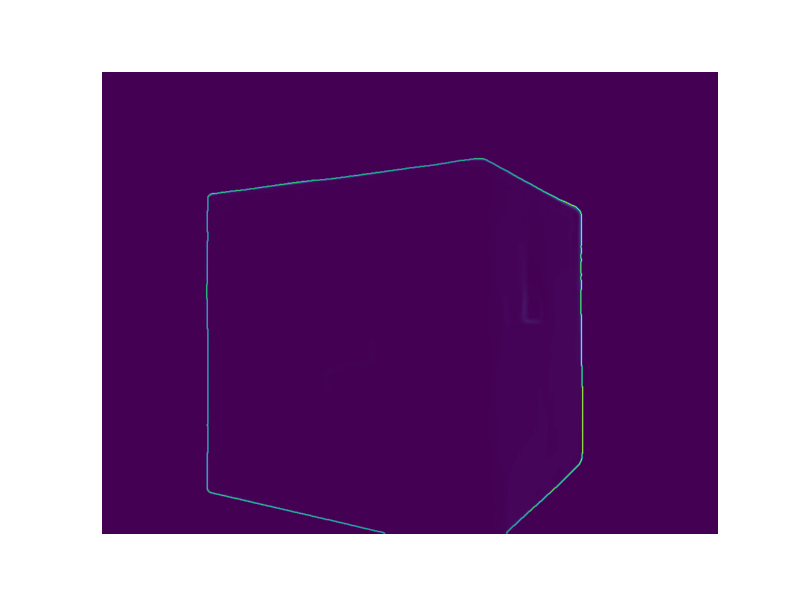

<IPython.core.display.Javascript object>


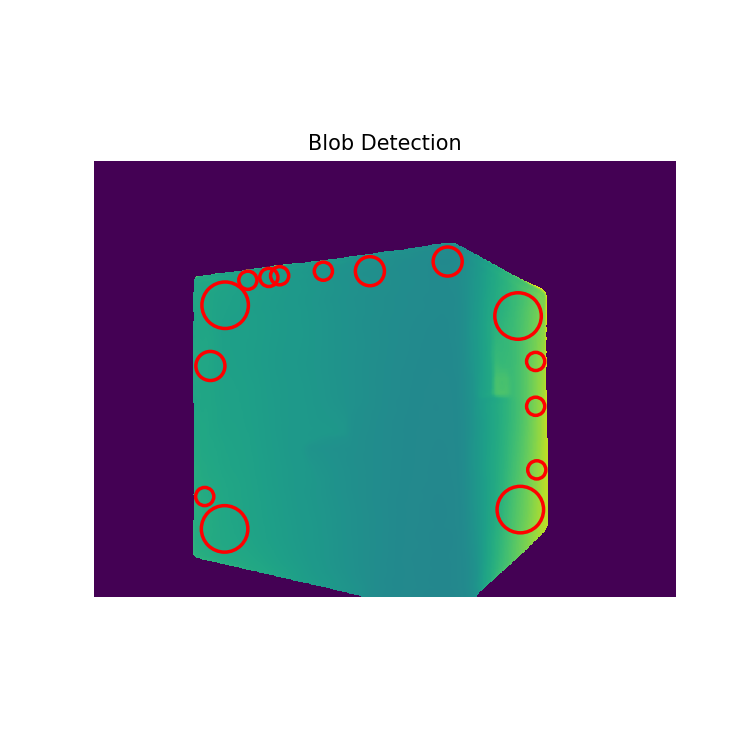

<IPython.core.display.Javascript object>


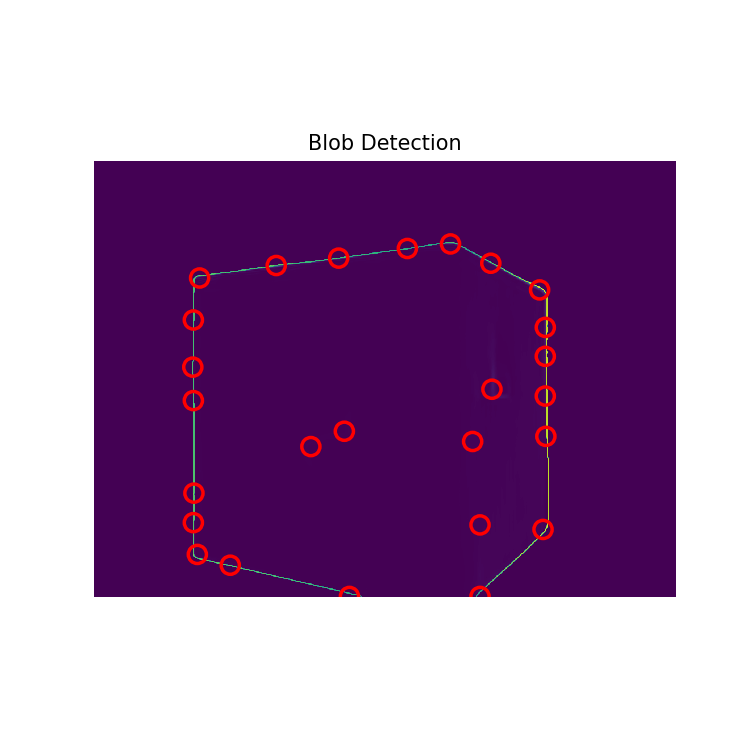

2.277615547180176


In [15]:
#Get Edges
edge_map = adjust_log(sobel(image_dep_m, mask=None,  axis=[0,1]))
plt.figure()
plt.axis("off")
plt.imshow(edge_map)
min_sigma = int(occ_R*.05)
max_sigma = int(occ_R*.15)

start = time.time()
# Blobs from Depth Map
blobs = detect_blobs(
    image_dep_m, 
    'dog', 
    min_sigma,
    max_sigma,
    threshold = 0.1)

# Blobs from Edge Map
edge_map_blobs = detect_blobs(
    edge_map, 
    'dog', 
    min_sigma,
    max_sigma,
    threshold = .001, 
)
print(time.time()-start)

### Canny Edge Detector Limitation & Some Solutions

The Canny Edge detector by itself does not give the strengths of the edges. This can be problematic as it may make it harder to detect self occlusions. To solve this, the edges from the canny edge detector are used as a mask for a gradient map. The gradients in this case can be calculated using the sobel filters. The results from the edge detection is a 2D map with lines representing edges. The edges appear to be too weak...
- **Challenge** &rarr; <span style="color:red">How to distinguish self occlusions from inner edges? _Further Normalisations?_</span> \
    _**Solution:** Regions of Intereset detected around occluded edges will solve this._
     
 
- **Challenge** &rarr; How to increase intensity of edges? \
    _**Solution:** Increase Exposure [[exposure_mehtods](https://scikit-image.org/docs/stable/api/skimage.exposure.html#skimage.exposure.adjust_log)]_

### Blobs

Edge regions are greatly detected by the blob detector at lower minimum sigma levels. A blob is defined by x,y cordinates and a radius: `(x, y, radius)`

- **Challenge** &rarr; <span style="color:red">For blob detections, how to determine optimum scales to check for(min & max sigmas) or thresholds or both?</span>

- **Challenge** &rarr; What blob method to use?\
    _**Solution:** Difference of Gaussians due to speed.


- **Challenge** &rarr; Are blobs from depth map or coloured image even necessary/adequate or will the edges do? That is detect blob from edge map as shown.\
    _**Solution:** 
    
    
- **Challenge** &rarr; <span style="color:red">How to aggregate the blobs to use</span>

   
## Discussion

### Edge Maps
A combination of Edge map and Depth Map processing provide optimum information gain. Edge maps provide an "edge" when comes to detecting geometrical edges in the image. This can help in detecting pockets, slots and even occlusions of the target object. Detection of edges is from grayscale images of the original images prove to be more reliable than from the corresponding depth maps. However, depth maps offer better results when it comes to self-occlusions.

The Sobel Operator was chosen over the Scharr and Canny Edge Detector. Like Sobel, Scharr is not a full-fledged edge detector but merely a convolutional kernel for gradient computation. It offers relatively more accurate results while offering low rotational variance [[source](https://scikit-image.org/docs/stable/auto_examples/edges/plot_edge_filter.html#sphx-glr-auto-examples-edges-plot-edge-filter-py)]. It however suffers more from sensitivity to noise compared to Sobel. The canny edge detector on the other hand is a more standardised filter for edge detection. It offers more accuracy, flexibility and robustness in edge detection. Canny Edge filter strvies to output fully connected edges while maintaining a relatively high level of edge thinness. The strengths of the Canny Edge is its weaknesses for the purpose of this study. This is where the Sobel operator does better, for starters, the Sobel filter can produce edges with gradient information which creates a distinction of features. To add on to feature distinction, thicker edges provide more utility in downstream processing. Moreover, the Sobel filter offers faster computation and in some cases better reliability where contrast is low over the Canny Edge detector.

<div style="display:flex;">
    <figure style="width:50%;">
        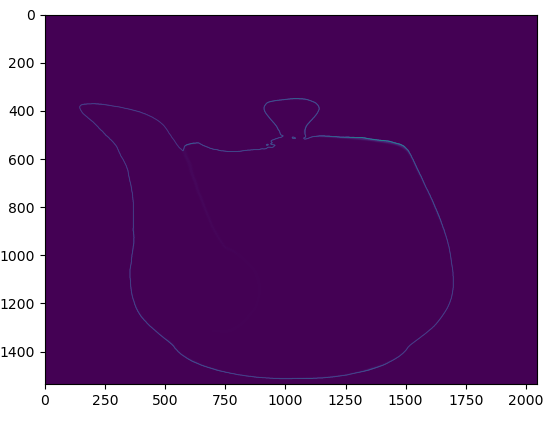
        <figcaption style="text-align:center">Original Edge Map</figcaption>
    </figure>
    <figure style="width:50%">
        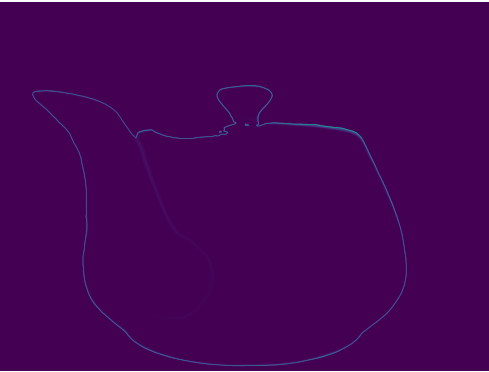
        <figcaption style="text-align:center">Logarithmic Corrected</figcaption>
    </figure>

</div>

The Sobel operator may produce edge maps that are quite faint. Enhanceements can be performed on such to produce more contrast in the edges. One such enhancement is the **logarithmic enhancement** offered as `adjust_log` from the scikit-image library.

# Point Cloud and Normal Visualisation

Creation of Point Clouds will be executed by Open3D. It essentially requires an RGB and Depth Image. The **Point cloud** plays a crucial role as it will provide coordinates as well as normals which are essential in defining the three-dimensional space. 

   * **Challenge**: How will we determine the radius and max_nn values during estimation of the normals? _Maybe it can be the factor of the blob radius_
   
Visualisation will be based on PyVista which supports convenient rendering of point clouds.

## Helper Functions

The cell below defines 3 functions `extract_single_blob_region()`, `create_point_cloud()` and `plot_normal()`. 

- `extract_single_blob_region` &rarr; Extract a single blob region from an image based on the provided blob details.
- `create_point_cloud` &rarr; Creates a point cloud from RGB and depth images using Open3D and returns the points and normals as numpy arrays.

- `plot_normal` &rarr; Plots the a point cloud of the blob in an interactive 3D widget. The function then calculates a normal for the blob section and plots it as an arrow at the centroid of the point cloud section.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import blob_log
from skimage.color import rgb2gray

def extract_single_blob_region(rgbd_combo, blob_details):
    """
    Extract a single blob region from an image based on the provided blob details.

    Parameters:
    - rgbd_combo (list): A list containing the Original RGB image and its depth map.
    - blob_details (tuple): Details of the blob (y-coordinate, x-coordinate, radius).

    Returns:
    - extracted_region (list): The extracted rgb and depth regions.
    """
    
    img_rgb, img_dep = rgbd_combo
    
    # Check for equality of image widths
    if img_rgb.shape[:2] != img_dep.shape[:2]:
        raise UnmatchedDimensionsException("The RDB and Depth Maps do not share common (2D)Dimensions")
        
    y, x, r = blob_details
    y, x, r = int(y), int(x), int(r)
    
    # Ensure the coordinates and radius do not go beyond image boundaries
    x_min = max(x - r, 0)
    x_max = min(x + r, img_rgb.shape[1])
    y_min = max(y - r, 0)
    y_max = min(y + r, img_rgb.shape[0])    
    
    # Extract the region
    extracted_region = list()
    extracted_region.append( img_rgb[y_min:y_max, x_min:x_max] )
    extracted_region.append( img_dep[y_min:y_max, x_min:x_max] )
    
    _, axs = plt.subplots( 1, 2, layout="constrained" )
    for ax, img, title, in zip( axs, extracted_region, ["RGB Image", "Depth Map"] ):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")
    
    plt.show()
    
    return extracted_region


def create_point_cloud(extractions, focal_l = 6):
    """
    Creates a point cloud from RGB and depth images using Open3D and returns the points and normals as numpy arrays.

    Parameters:
    - extractions (tuple): A tuple containing two elements, img_rgb and img_dep.
      img_rgb (numpy.ndarray): The RGB image as a numpy array.
      img_dep (numpy.ndarray): The depth image as a numpy array.
    - focal_l (float): The focal length of the camera. Default is 6.

    Returns:
    - pcd_p (numpy.ndarray): An array of 3D points from the point cloud.
    - pcd_n (numpy.ndarray): An array of corresponding normals for each point in the point cloud.
    """
    img_rgb, img_dep = extractions
    
    # Scaling factor for the depth image
    _scale = 1000
    
    # Image dimensions
    img_width = img_rgb.shape[1]
    img_height = img_rgb.shape[0]
    color_raw_m = o3d.geometry.Image(img_rgb)
    depth_raw_m =  o3d.geometry.Image(img_dep*_scale) 

    # Create RGBD 
    rgbd_image_m = o3d.geometry.RGBDImage.create_from_color_and_depth(
        color_raw_m, 
        depth_raw_m
    )

    # Create Point Cloud
    pcd = o3d.geometry.PointCloud.create_from_rgbd_image( rgbd_image_m, intrinsics )

    # Estimate Normals
    pcd.estimate_normals( search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=.1, max_nn=30))
    pcd.orient_normals_towards_camera_location()

    # Create Numpy Arrays for the points and corresponding normals.
    pcd_p = np.asarray(pcd.points)
    pcd_n = np.asarray(pcd.normals)
    
    '''
    # Visualise with Open3D
    bba = pcd.get_axis_aligned_bounding_box()
    bba.color = (1,0,0)
    o3d.visualization.draw_geometries([pcd, bba], 
                                  point_show_normal=True,
                                  zoom=.2,
                                  front=[0, 0, -1],
                                  lookat=[0, 0, 0],
                                  up=[0, -1, 0] )    
    '''
    return pcd_p, pcd_n

def plot_normal(points, normals):
    """
    Calculate the centroid of a set of points, find the normal closest to the centroid,
    and add an arrow representing this normal to the PyVista plotter.

    Parameters:
    - points (numpy.ndarray): Points array of shape (_, 3).
    - normals (numpy.ndarray): Normals array of shape (_, 3).
    - plotter (pyvista.Plotter): An instance of a PyVista Plotter.

    Returns:
    - centroid (numpy.ndarray): The centroid of the points.
    - plotter (pyvista.Plotter): The updated PyVista Plotter with the arrow added.
    """
    # Calculate the centroid
    centroid = np.mean(points, axis=0)

    # Find the index of the point closest to the centroid
    distances = np.linalg.norm(points - centroid, axis=1)
    closest_point_index = np.argmin(distances)

    # Get the normal at the closest point
    closest_normal = normals[closest_point_index]

    plotter = pv.Plotter()
    # Add an arrow representing the normal at the centroid
    arrow = pv.Arrow(start=centroid, direction=closest_normal, scale=1)  # Adjust scale as needed
    plotter.add_mesh(arrow, color='red')
    
    # Create the PyVista PolyData for the point cloud
    pv_cloud = pv.PolyData(points)
    plotter.add_points(pv_cloud, point_size=2, render_points_as_spheres=True)
    
    # Other plot settings
    plotter.view_xy()
    plotter.show_axes()
    plotter.show_grid()
    plotter.show()


### Execution and Visualisations

1. Pick a blob to use from the list of blobs generated priorly.
2. Extract the blob from out of the RGB and depth images
3. Create a point cloud and Compute their corresponding normals
4. Use the point cloud and normals to get a single normal for the whole section that can be plotted using PyVista

<IPython.core.display.Javascript object>


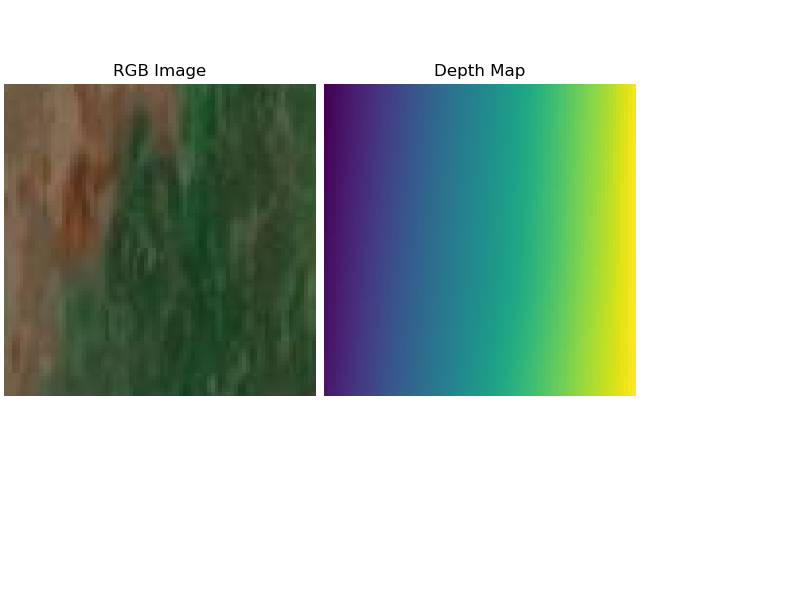

Widget(value="<iframe src='http://localhost:34901/index.html?ui=P_0x7f2fbeb72910_1&reconnect=auto' style='widt…

In [17]:
# Select a random blob from Figure 3
blob = blobs[0]

extract = extract_single_blob_region([image_col_m, image_dep_m], blob)
points, normals = create_point_cloud( extract )

plot_normal(points, normals)

In [18]:
# Run this cell to show Cached interactive 3D result
from IPython.display import display, HTML, IFrame

display(IFrame(src="Attachments/normal_singleblob.html", width='800', height='500'))
print("Example of a normal for a random blob")

Example of a normal for a random blob


### Observations

- A blob region was cropped from the origial Colour and Depth Images(Fig 1) to get what there is in **Figure 5**. 
- Generation of a point cloud requires a colour image and its corresponding depth map to make and [**RGBD**](http://www.open3d.org/docs/release/tutorial/geometry/rgbd_image.html) image. 
- The RGBD image will be the basis of [**Point Cloud generation**](http://www.open3d.org/docs/release/tutorial/geometry/pointcloud.html). 
- With the Point Cloud, normals are then computed.
- `create_point_cloud()` returns the point cloud as well as normal for each point to be used in downstream proceses.

The figure embedded above shows the blob regions extracted from the original colour and depth maps. The dept

<iframe src="Attachments/normal_singleblob.html" title="Single Normal from a Blob"></iframe>

* **Challenge**: How will the normal arrow be scaled?

* **Challenge**: What scale for the points?

### Plot with respect to the whole Point Cloud

To ascertain that indeed the normals have been calculated in order with respect to the rest of the target object, we attempt to visualise the normal alongside the whole point cloud, that is, the point generated not from a blob but the orignal masked colour and depth images which represent the whole target object.

Therefore, we calculate a point cloud for the target object(RGBD of masked colour and depth image). 

In [21]:
def add_normal_to_plotter(points, normals, plotter):
    """
    Calculate the centroid of a set of points, find the normal closest to the centroid,
    and add an arrow representing this normal to the PyVista plotter.

    Parameters:
    - points (numpy.ndarray): Points array of shape (_, 3).
    - normals (numpy.ndarray): Normals array of shape (_, 3).
    - plotter (pyvista.Plotter): An instance of a PyVista Plotter.

    Returns:
    - centroid (numpy.ndarray): The centroid of the points.
    - plotter (pyvista.Plotter): The updated PyVista Plotter with the arrow added.
    """
    # Calculate the centroid
    centroid = np.mean(points, axis=0)
    
    print(f"Centroid at: {centroid}")

    # Find the index of the point closest to the centroid
    distances = np.linalg.norm(points - centroid, axis=1)
    closest_point_index = np.argmin(distances)

    # Get the normal at the closest point
    closest_normal = normals[closest_point_index]

    # Add an arrow representing the normal at the centroid
    arrow = pv.Arrow(start=centroid, direction=closest_normal, scale=.36)  # Adjust scale as needed
    plotter.add_mesh(arrow, color='red')

    return plotter, centroid, closest_normal

<IPython.core.display.Javascript object>


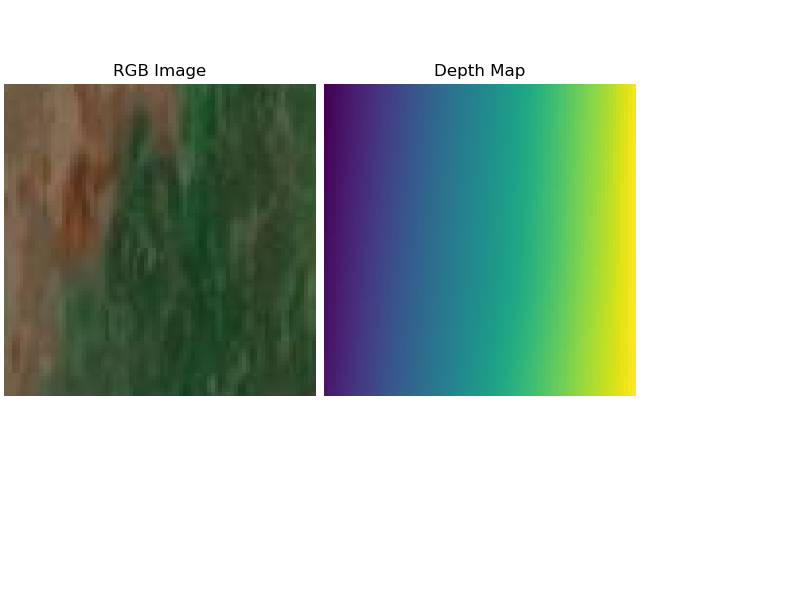

Centroid at: [-1.33904072 -0.95251856  2.69649749]


Widget(value="<iframe src='http://localhost:34901/index.html?ui=P_0x7f2fbea3f610_3&reconnect=auto' style='widt…

In [22]:
blob = blobs[0]
extract = extract_single_blob_region([image_col_m, image_dep_m], blob)
points, normals = create_point_cloud( extract )


viewpoint_points, viewpoint_normals = create_point_cloud( [ image_col_m, image_dep_m ] )

plotter = pv.Plotter()

vp_cloud = pv.PolyData(viewpoint_points)
plotter.add_points(vp_cloud, point_size=2, render_points_as_spheres=True)

plotter, centroid, normal = add_normal_to_plotter(points, normals, plotter)

# Other plot settings
plotter.view_xy()
plotter.show_axes()
plotter.show_grid()
plotter.show()

In [23]:
# Run this cell to show Cached interactive 3D result
from IPython.display import display, HTML, IFrame

display(IFrame(src="Attachments/incorrect_normal.html", width='800', height='500'))
print("An incorrect Normal Estimation")

An incorrect Normal Estimation


## Observations

It seems that the spatial information from above is not right. First, the camera intrinisics should be computed with respect to the standard image from the image, not a cropped version of the image. This is cruical as computing it based on a cropped image results in incorrect scaling.
    
   **NB: This was corrected by removing the codeblock below which was initially in create_point_cloud() and placed in code cell #3**
    
~~~python
fx, fy = (focal_l *  img_width/6.287, focal_l *  img_width/6.287)
cx, cy = ( img_width/2, img_height/2 )
intrinsics = o3d.camera.PinholeCameraIntrinsic(img_width, img_height, fx, fy, cx, cy)
~~~

As for the inacurrate spatial positioning of the normal, one possible cause might that cropping the blob loses "relative context". Thus, we calculate the normal of a given blob quite like previously, except that this time instead of cropping the blob region, we isolate the blob region from the rest of the image by maskin out the rest of the image using the `isolate_image()` below.

Blob Properties: [614.   751.    40.96]


<IPython.core.display.Javascript object>


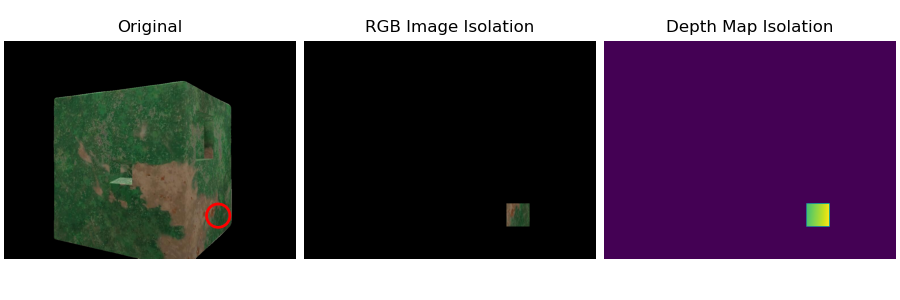

Centroid at: [0.62016513 0.62849933 2.69039799]


Widget(value="<iframe src='http://localhost:34901/index.html?ui=P_0x7f2fc42d32b0_4&reconnect=auto' style='widt…

In [24]:
def isolate_image(image, roi):
    """
    Processes the image to black out everything except for a square region of interest.
    
    :param image: numpy array, the original image
    :param roi: list or tuple, [y, x, radius] defining the region of interest
    :return: numpy array, the processed image
    """
    # Extracting the center (y, x) and radius
    y, x, radius = roi
    
    # Calculating the square bounds
    top_y = max(int(y - radius), 0)
    left_x = max(int(x - radius), 0)
    bottom_y = min(int(y + radius), image.shape[0])
    right_x = min(int(x + radius), image.shape[1])

    # Create 
    masked = np.zeros_like(image)    
    cropped_image = image[top_y:bottom_y, left_x:right_x]
    masked[top_y:bottom_y, left_x:right_x] = cropped_image

    return masked

blob = blobs[0]
print(f"Blob Properties: {blob}")

canvas_col = isolate_image( image_col_m, blob )
canvas_dep = isolate_image( image_dep_m, blob )
isolation = [ canvas_col, canvas_dep ]

_, axs = plt.subplots( 1, 3, figsize=(9,3), layout="constrained" )
for ax, img, title, in zip( axs, [image_col_m, *isolation], ["Original","RGB Image Isolation", "Depth Map Isolation"] ):
    ax.imshow(img)
    ax.set_title(title)
    if title == "Original":
        y, x, r = blob
        c = plt.Circle((x, y), r, color='red', linewidth=2, fill=False)
        ax.add_patch(c)
    ax.axis("off")

plt.show()

points, normals = create_point_cloud( isolation )
viewpoint_points, viewpoint_normals = create_point_cloud( [ image_col_m, image_dep_m ] )

plotter = pv.Plotter()
vp_cloud = pv.PolyData(viewpoint_points)
plotter.add_points(vp_cloud, point_size=2, render_points_as_spheres=True)

plotter, centroid, normal = add_normal_to_plotter(points, normals, plotter)

length = .8;
newPose = (normal * length) + centroid

# Define the center and radius of the sphere
sphere_center = newPose  # Replace with the desired coordinates
sphere_radius = 0.07  # Adjust the radius as needed

# Create and add a sphere to represent a single point
sphere = pv.Sphere(radius=sphere_radius, center=sphere_center)
plotter.add_mesh(sphere, color='green')

plotter.view_yx()
plotter.show_axes()
plotter.show_grid()
plotter.show()

In [ ]:
# Run this cell to show Cached interactive 3D result
from IPython.display import display, HTML, IFrame

display(IFrame(src="Attachments/colliding_normal.html", width='800', height='500'))
print("A Rightly Estimated but colliding Normal")

### Observations

From the figure above, the normal has been estimated correctly, however, deriving a pose out of that may not be as simple as choosing a point in the neighbourhood of the green sphere as there is a hight chance of **collision**.

- **Challenge** &rarr; How to ensure collision free poses?\
    _**Solution:** Create a constraint that considers the angle between the point_

Trying a different Blob:

Blob Properties: [614.   751.    40.96]


<IPython.core.display.Javascript object>


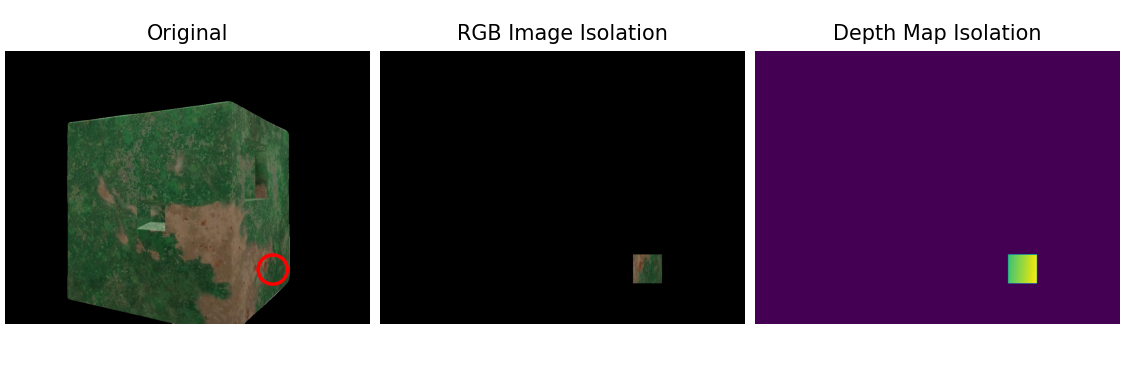

Centroid at: [0.62016513 0.62849933 2.69039799]


Widget(value="<iframe src='http://localhost:34901/index.html?ui=P_0x7f2fbe3ebbb0_5&reconnect=auto' style='widt…

In [25]:
blob = blobs[0]
print(f"Blob Properties: {blob}")

canvas_col = isolate_image( image_col_m, blob )
canvas_dep = isolate_image( image_dep_m, blob )
isolation = [ canvas_col, canvas_dep ]

_, axs = plt.subplots( 1, 3, figsize=(9,3), layout="constrained" )
for ax, img, title, in zip( axs, [image_col_m, *isolation], ["Original","RGB Image Isolation", "Depth Map Isolation"] ):
    ax.imshow(img)
    ax.set_title(title)
    if title == "Original":
        y, x, r = blob
        c = plt.Circle((x, y), r, color='red', linewidth=2, fill=False)
        ax.add_patch(c)
    ax.axis("off")

plt.show()

points, normals = create_point_cloud( isolation )
viewpoint_points, viewpoint_normals = create_point_cloud( [ image_col_m, image_dep_m ] )

plotter = pv.Plotter()
vp_cloud = pv.PolyData(viewpoint_points)
plotter.add_points(vp_cloud, point_size=2, render_points_as_spheres=True)

plotter, centroid, normal = add_normal_to_plotter(points, normals, plotter)

length = 1.4308777633978396
newPose = (normal * length) + centroid

# Define the center and radius of the sphere
sphere_radius = 0.05  # Adjust the radius as needed
sphere = pv.Sphere(radius=sphere_radius, center=newPose)

# Define the Viewpoint Anchor
anchorCenter = np.mean(viewpoint_points, axis=0) 
sphere_radius = 0.07  # Adjust the radius as needed
anchorSphere = pv.Sphere(radius=sphere_radius, center=anchorCenter)

# Define the Secondary Point
sec_pose = np.asarray([1.96835419, 1.08254574, 2.84414874])
secPoseSphere = pv.Sphere(radius=0.07, center=sec_pose)


plotter.add_mesh(sphere, color='green')

plotter.add_mesh(anchorSphere, color='blue')

plotter.add_mesh(secPoseSphere, color='red')


"""
Get Orientations
"""
# primary pose orientation
newPose_vec = (centroid-newPose)
magnitude = np.linalg.norm(newPose_vec)
newPoseO = newPose_vec / magnitude
arrow = pv.Arrow(start=newPose, direction=newPoseO, scale=.3)  # Adjust scale as needed
plotter.add_mesh(arrow, color='blue')

# primary pose orientation
secPose_vec = (centroid-sec_pose)
magnitude = np.linalg.norm(secPose_vec)
secPoseO = secPose_vec / magnitude
arrow = pv.Arrow(start=sec_pose, direction=secPoseO, scale=.3)  # Adjust scale as needed
plotter.add_mesh(arrow, color='red')


plotter.view_yx()
plotter.show_axes()
plotter.show_grid()
plotter.show()

In [ ]:
magnitude = np.linalg.norm((centroid-newPose))
normalized_vector = (centroid-newPose) / magnitude
normalized_vector

In [ ]:
# Run this cell to show Cached interactive 3D result
from IPython.display import display, HTML, IFrame

display(IFrame(src="Attachments/correct_normal.html", width='800', height='500'))
print("A Rightly Estimated Normal")

# Calculating Poses

Now we have the spatial information of the regions on the target object where we need to put special emphasis during the image acquisition process. How can this infromation be capitalised on for calculation of Next Best Views?

From Preliminary Experiments 3, it was observed that viewpoints that had a pitch towards the centroid of the depth map would yield better reconstruction results. This probably because of increased overlap which improved image-matching computations. To capitalise on this, the normal of the ROI will give a viewpoint perpendicular to it, a secondary viewpoint will be provided that will be a function of the angle between the perpendicular viewpoint, the ROI and the global centroid of the point cloud.]


- **Challenge**: Distance of perpendicular view point.\
   _**Solution:**_ The distance be a function of the ROI radius.

In [ ]:
# Create Point Complete Point Cloud First
viewpoint_points, viewpoint_normals = create_point_cloud( [ image_col_m, image_dep_m ] )
viewpoint_Centroid = np.mean(viewpoint_points, axis=0)

index = 0

blob = blobs[index]

# Get Closest Point to the Camera
WD = np.min(image_dep_m[image_dep_m > 0])

# Baseline ROI Radius(Max)
roi_R =  np.max(blobs[:,2:])

# ROI Working Distance
wd = (int(blob[2])/max_sigma) * WD


canvas_col = isolate_image( image_col_m, blob )
canvas_dep = isolate_image( image_dep_m, blob )
isolation = [ canvas_col, canvas_dep ]
points, normals = create_point_cloud( isolation )

# Calculate the centroid
centroid = np.mean(points, axis=0)

print(f"Centroid at: {centroid}")

# Find the index of the point closest to the centroid
distances = np.linalg.norm(points - centroid, axis=1)
closest_point_index = np.argmin(distances)

# Get the normal at the closest point
normal = normals[closest_point_index]

newPose = (normal * length) + centroid

print(f"New Pose at: {newPose}")
print(f"Viewpoint Center: {viewpoint_Centroid}")

# Create vectors
v1 = newPose - centroid
v2 = viewpoint_Centroid - centroid

# Calculate dot product
dot_product = np.dot(v1, v2)

# Calculate magnitudes
magnitude_v1 = np.linalg.norm(v1)
magnitude_v2 = np.linalg.norm(v2)

# Calculate the angle in radians
angle_radians = np.arccos(dot_product / (magnitude_v1 * magnitude_v2))

# Convert to degrees, if desired
angle_degrees = np.degrees(angle_radians)



print("Angle in radians:", angle_radians)
print("Angle in degrees:", angle_degrees)

In [ ]:
"""
Compute Secondary Pose using Open3D
"""

start = time.time()
# Compute the normal vector to the plane (perpendicular to the plane)
normal = np.cross(v1, v2)
axis_normalized = normal / np.linalg.norm(normal)

# Define the angle theta in degrees
theta = -(180-angle_degrees)/2

# Convert theta to radians
theta_radians = np.radians(theta)

# Create a rotation matrix using Open3D or NumPy
R = o3d.geometry.get_rotation_matrix_from_axis_angle(theta_radians * axis_normalized)

# Rotate the vector P1-P2 using the rotation matrix
rotated_vector = np.dot(R, v1)

# Find the new position P1_new
P1_new = rotated_vector + centroid

print(time.time()-start)
P1_new

In [ ]:
"""
Compute Secondary Pose using SciPy
"""

from scipy.spatial.transform import Rotation as R
start = time.time()
# Compute the normal vector to the plane (perpendicular to the plane)
normal = np.cross(v1, v2)

# Normalize the normal vector
axis_normalized = normal / np.linalg.norm(normal)

# Define the angle theta in degrees
theta = -(180-angle_degrees)/2  # replace with the value of theta in degrees

# Convert theta to radians
theta_radians = np.radians(theta)

# Create a quaternion for the rotation
quat = R.from_rotvec(theta_radians * axis_normalized)

# Rotate the vector P1-P2
rotated_vector = quat.apply(v1)

# Find the new position P1_new
P1_new = rotated_vector + centroid
print(time.time()-start)
P1_new


In [ ]:
print(time.time() - begin)

In [ ]:
0.0012042522430419922/0.0003628730773925781
